# 코호트 재구매율 분석

`RFM_4rd_processed`에서 분리한 탐색적 코호트 분석 노트북.

**독립 실행:** `retail_preprocessed.parquet`만 로드하면 되며, RFM/패널/군집화 파이프라인과 무관하다.

**취소 처리:** 데이터는 net-sales 방식이라 취소(C 인보이스·음수 수량) 행이 살아 있다.
코호트는 "구매 시점"만 보므로, 코호트월 산출과 재구매 판정 모두 `is_purchase`(정상 구매)만 사용한다.
Monetary≤0 제거 등 RFM 전용 처리는 코호트에 불필요하므로 적용하지 않는다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 윈도우 기준 한글 폰트
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 데이터 로드 (00_전처리 산출물 — is_purchase / is_cancel 포함) ──
df = pd.read_parquet('../data/retail_preprocessed.parquet')

# 회원만 (비회원은 고객 귀속 불가 → 코호트 분석 대상 아님)
df = df.dropna(subset=['Customer ID']).copy()

print("로드 완료:", df.shape)
print("is_purchase 컬럼 존재:", 'is_purchase' in df.columns)
print("취소(is_cancel) 행:", int(df['is_cancel'].sum()) if 'is_cancel' in df.columns else 'N/A')

로드 완료: (794165, 13)
is_purchase 컬럼 존재: True
취소(is_cancel) 행: 17586


In [2]:
# ============================================================
# 코호트 컬럼 생성 (★ 정상구매 is_purchase 기준)
#   - 취소월이 코호트로 잡히는 것 방지
#   - 취소 거래에도 경과월은 붙지만, 재구매 판정 단계에서 is_purchase로 다시 거른다
# ============================================================

df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

# 코호트월 = 정상구매의 첫 달
pur = df[df['is_purchase']]
df['CohortMonth'] = df['Customer ID'].map(
    pur.groupby('Customer ID')['InvoiceMonth'].min()
)

# 정상구매가 하나도 없는 고객(취소전용)은 CohortMonth = NaN → 경과월도 NaN
df['PeriodNumber'] = (df['InvoiceMonth'] - df['CohortMonth']).apply(
    lambda x: x.n if pd.notna(x) else np.nan
)

print("취소전용 고객(코호트 결측) 행:", int(df['CohortMonth'].isna().sum()))
print(df[['Customer ID', 'CohortMonth', 'PeriodNumber']].head())

취소전용 고객(코호트 결측) 행: 87
  Customer ID CohortMonth  PeriodNumber
0       13085     2009-12           0.0
1       13085     2009-12           0.0
2       13085     2009-12           0.0
3       13085     2009-12           0.0
4       13085     2009-12           0.0


In [3]:
inv = df['Invoice'].astype(str)

# ── 1. 전체 거래 중 취소 비율 ──
n_total   = len(df)
n_cancel  = int(df['is_cancel'].sum()) if 'is_cancel' in df.columns else int((df['Quantity']<0).sum())
print(f"[1] 전체 행 {n_total:,} 중 취소 {n_cancel:,}건 = {n_cancel/n_total*100:.2f}%")



[1] 전체 행 794,165 중 취소 17,586건 = 2.21%


In [4]:
inv = df['Invoice'].astype(str)

# ── 금액 기준 취소 비중 (이게 제일 정확한 '취소 무게') ──
pur_sales = df[df['is_purchase']]['Sales'].sum()      # 정상구매 총액
can_sales = -df[inv.str.startswith('C')]['Sales'].sum()  # 취소 총액(양수화)
print(f"\n=== 금액 기준 ===")
print(f"정상구매 총액: {pur_sales:,.0f}")
print(f"취소 총액:     {can_sales:,.0f}")
print(f"금액 기준 취소 비중: {can_sales/pur_sales*100:.2f}%")

# ── 수량 기준 취소 비중 ──
pur_qty = df[df['is_purchase']]['Quantity'].sum()
can_qty = -df[inv.str.startswith('C')]['Quantity'].sum()
print(f"\n=== 수량 기준 ===")
print(f"정상구매 수량: {pur_qty:,.0f}")
print(f"취소 수량:     {can_qty:,.0f}")
print(f"수량 기준 취소 비중: {can_qty/pur_qty*100:.2f}%")


=== 금액 기준 ===
정상구매 총액: 17,016,771
취소 총액:     709,953
금액 기준 취소 비중: 4.17%

=== 수량 기준 ===
정상구매 수량: 10,498,738
취소 수량:     464,292
수량 기준 취소 비중: 4.42%


In [5]:
inv = df['Invoice'].astype(str)
m12 = df[(df['CohortMonth'].astype(str)=='2009-12') & inv.str.startswith('C')]

print("2009-12 취소수량 상위 고객:")
print(m12.groupby('Customer ID')['Quantity'].sum().abs().sort_values(ascending=False).head(5).to_string())

# 12346이 어느 코호트인지
c = df[df['Customer ID'].astype(str)=='12346']
print("\n12346 코호트:", c['CohortMonth'].iloc[0])

2009-12 취소수량 상위 고객:
Customer ID
14277    87919
12931    13667
15838     9479
14911     6450
16029     6444

12346 코호트: 2010-03


In [6]:
import pandas as pd
import numpy as np

inv = df['Invoice'].astype(str)

# ── (코호트 컬럼 없으면 먼저 생성) ──
# df = df.dropna(subset=['Customer ID']).copy()
# df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
# pur = df[df['is_purchase']]
# df['CohortMonth'] = df['Customer ID'].map(pur.groupby('Customer ID')['InvoiceMonth'].min())

# ── 코호트별 정상구매 수량 / 취소 수량 ──
df['_is_cancel'] = inv.str.startswith('C')

# 정상구매 수량 (코호트별)
pur_qty = (df[df['is_purchase']]
           .groupby('CohortMonth')['Quantity'].sum()
           .rename('구매수량'))

# 취소 수량 (코호트별, 양수화)
can_qty = (df[df['_is_cancel']]
           .groupby('CohortMonth')['Quantity'].sum()
           .abs()
           .rename('취소수량'))

# 합쳐서 비중 계산
cohort_cancel = pd.concat([pur_qty, can_qty], axis=1).fillna(0)
cohort_cancel['취소비중(%)'] = (cohort_cancel['취소수량'] /
                              cohort_cancel['구매수량'] * 100).round(2)

# 코호트월을 문자열로 (보기 좋게)
cohort_cancel.index = cohort_cancel.index.astype(str)

print("=== 코호트별 수량 취소 비중 ===")
print(cohort_cancel.to_string())

# 전체 평균도 같이
tot_pur = df[df['is_purchase']]['Quantity'].sum()
tot_can = abs(df[df['_is_cancel']]['Quantity'].sum())
print(f"\n전체: 구매 {tot_pur:,.0f} / 취소 {tot_can:,.0f} = {tot_can/tot_pur*100:.2f}%")

df.drop(columns='_is_cancel', inplace=True)

=== 코호트별 수량 취소 비중 ===
                구매수량    취소수량  취소비중(%)
CohortMonth                          
2009-12      5128675  204702     3.99
2010-01       783172   14118     1.80
2010-02       590869   10736     1.82
2010-03       837879   93634    11.18
2010-04       319044    4522     1.42
2010-05       243691    2427     1.00
2010-06       387151    6561     1.69
2010-07       172874    3851     2.23
2010-08       151984     916     0.60
2010-09       366812    9053     2.47
2010-10       278815    7704     2.76
2010-11       216863    2449     1.13
2010-12        35010     652     1.86
2011-01        70426    9838    13.97
2011-02       106940     919     0.86
2011-03       141247    3387     2.40
2011-04        58893     518     0.88
2011-05       149693   81559    54.48
2011-06        69651    1287     1.85
2011-07        59551     444     0.75
2011-08        68403     317     0.46
2011-09        93404    1530     1.64
2011-10        95011    1848     1.95
2011-11        60023     555

In [7]:
inv = df['Invoice'].astype(str)
m12 = df[df['CohortMonth'].astype(str)=='2009-12']

# ① 취소가 특정 소수 고객/거래에 쏠렸나 (12346 같은 이상치)
can12 = m12[inv.str.startswith('C')]
print("2009-12 취소 수량:", abs(can12['Quantity'].sum()))
print("\n취소 수량 상위 고객:")
print(can12.groupby('Customer ID')['Quantity'].sum().abs().sort_values(ascending=False).head(5).to_string())

# ② orphan 성격: 12월에 취소만 있고 그 이전 정상구매가 데이터에 없는 고객
#    (첫 거래가 취소이거나, 취소가 첫 구매보다 앞선 고객)
first_pur = m12[m12['is_purchase']].groupby('Customer ID')['InvoiceDate'].min()
first_can = can12.groupby('Customer ID')['InvoiceDate'].min()
orphan_like = [c for c in first_can.index if c not in first_pur.index or first_can[c] < first_pur.get(c, pd.Timestamp.max)]
print(f"\n취소가 원구매보다 앞서거나 원구매 없는 고객: {len(orphan_like)}명")
orphan_can = can12[can12['Customer ID'].isin(orphan_like)]['Quantity'].abs().sum()
print(f"그 고객들의 취소 수량: {orphan_can:,.0f} / 전체 취소 {abs(can12['Quantity'].sum()):,.0f} = {orphan_can/abs(can12['Quantity'].sum())*100:.1f}%")

2009-12 취소 수량: 204702

취소 수량 상위 고객:
Customer ID
14277    87919
12931    13667
15838     9479
14911     6450
16029     6444

취소가 원구매보다 앞서거나 원구매 없는 고객: 58명
그 고객들의 취소 수량: 95,864 / 전체 취소 204,702 = 46.8%


C:\Users\rladp\AppData\Local\Temp\ipykernel_33920\412370764.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  can12 = m12[inv.str.startswith('C')]


In [8]:
# 2010-03 코호트의 취소를 누가/뭘 냈나
inv = df['Invoice'].astype(str)
m3 = df[(df['CohortMonth'].astype(str)=='2010-03') & inv.str.startswith('C')]

print("2010-03 코호트 취소 라인:", len(m3), "| 취소 고객 수:", m3['Customer ID'].nunique())
print("\n=== 취소 수량 상위 고객 ===")
print(m3.groupby('Customer ID')['Quantity'].sum().abs().sort_values(ascending=False).head(5))
print("\n=== 취소 수량 상위 인보이스 ===")
print(m3.groupby('Invoice')['Quantity'].sum().abs().sort_values(ascending=False).head(5))
print("\n=== 취소 수량 상위 상품 ===")
print(m3.groupby('StockCode')['Quantity'].sum().abs().sort_values(ascending=False).head(5))

2010-03 코호트 취소 라인: 1309 | 취소 고객 수: 219

=== 취소 수량 상위 고객 ===
Customer ID
12346    74215
16754     8953
17133     1088
12908      600
15027      578
Name: Quantity, dtype: int64

=== 취소 수량 상위 인보이스 ===
Invoice
C541433    74215
C513771     6584
C513994     1236
C520205     1088
C513780      760
Name: Quantity, dtype: int64

=== 취소 수량 상위 상품 ===
StockCode
23166    74216
21679      864
21086      768
21749      720
21704      648
Name: Quantity, dtype: int64


In [9]:
c = df[df['Customer ID']=='12346']
print(c.groupby('Invoice').agg(
    상품=('StockCode', lambda s: s.iloc[0]),
    수량=('Quantity','sum'),
    날짜=('InvoiceDate','first')
).to_string())

            상품     수량                  날짜
Invoice                                  
499763   20682      5 2010-03-02 13:08:00
513774   21524     19 2010-06-28 13:53:00
541431   23166  74215 2011-01-18 10:01:00
C541433  23166 -74215 2011-01-18 10:17:00


In [10]:
# ============================================================
# 1. 고객별 첫 재구매 시점 (★ 정상구매만)
#    FirstRepurchase = 첫 구매 이후 처음 재구매까지 걸린 개월 수, 없으면 NaN
# ============================================================
customer_repurchase = df[df['is_purchase']].groupby('Customer ID').agg(
    CohortMonth     = ('CohortMonth', 'first'),
    FirstRepurchase = ('PeriodNumber', lambda x: x[x >= 1].min())
).reset_index()

customer_repurchase['CohortStr'] = customer_repurchase['CohortMonth'].astype(str)
print("고객 수:", len(customer_repurchase))
print("재구매 있는 고객:", customer_repurchase['FirstRepurchase'].notna().sum())

고객 수: 5852
재구매 있는 고객: 4094


In [11]:
for cid in ['12346', '16754', '17133']:
    c = df[df['Customer ID'].astype(str)==cid]
    pur = c[c['is_purchase']]['Quantity'].sum()
    can = abs(c[df['Invoice'].astype(str).str.startswith('C')]['Quantity'].sum())
    print(f"\n===== 고객 {cid} =====")
    print(f"정상구매 수량: {pur:,.0f} | 취소 수량: {can:,.0f} | 순수량: {pur-can:,.0f}")
    print(f"취소/구매 비율: {can/pur*100:.1f}%" if pur>0 else "구매 없음(취소전용)")
    # 취소 상위 상품
    can_rows = c[df['Invoice'].astype(str).str.startswith('C')]
    print("취소 상위 상품:")
    print(can_rows.groupby('StockCode')['Quantity'].sum().abs().sort_values(ascending=False).head(3).to_string())

C:\Users\rladp\AppData\Local\Temp\ipykernel_33920\744684557.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  can = abs(c[df['Invoice'].astype(str).str.startswith('C')]['Quantity'].sum())
C:\Users\rladp\AppData\Local\Temp\ipykernel_33920\744684557.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  can_rows = c[df['Invoice'].astype(str).str.startswith('C')]



===== 고객 12346 =====
정상구매 수량: 74,239 | 취소 수량: 74,215 | 순수량: 24
취소/구매 비율: 100.0%
취소 상위 상품:
StockCode
23166    74215


C:\Users\rladp\AppData\Local\Temp\ipykernel_33920\744684557.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  can = abs(c[df['Invoice'].astype(str).str.startswith('C')]['Quantity'].sum())
C:\Users\rladp\AppData\Local\Temp\ipykernel_33920\744684557.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  can_rows = c[df['Invoice'].astype(str).str.startswith('C')]



===== 고객 16754 =====
정상구매 수량: 63,551 | 취소 수량: 8,953 | 순수량: 54,598
취소/구매 비율: 14.1%
취소 상위 상품:
StockCode
21679    864
21086    768
21749    720

===== 고객 17133 =====
정상구매 수량: 10,107 | 취소 수량: 1,088 | 순수량: 9,019
취소/구매 비율: 10.8%
취소 상위 상품:
StockCode
85123A    320
84755     288
22469     120


C:\Users\rladp\AppData\Local\Temp\ipykernel_33920\744684557.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  can = abs(c[df['Invoice'].astype(str).str.startswith('C')]['Quantity'].sum())
C:\Users\rladp\AppData\Local\Temp\ipykernel_33920\744684557.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  can_rows = c[df['Invoice'].astype(str).str.startswith('C')]


In [12]:
# ============================================================
# 2. 코호트별 N개월 이내 누적 재구매율
#    N개월 내 재구매 = 첫 재구매가 p개월 이내 (FirstRepurchase <= p)
# ============================================================
periods = [1, 3, 6, 9, 12]
cohort_list = sorted(customer_repurchase['CohortStr'].unique())

cumulative_data = []
for cohort in cohort_list:
    cohort_customers = customer_repurchase[customer_repurchase['CohortStr'] == cohort]
    row = {'Cohort': cohort, '신규유입': len(cohort_customers)}
    for p in periods:
        rate = (cohort_customers['FirstRepurchase'] <= p).mean() * 100
        row[f'+{p}개월'] = rate
    cumulative_data.append(row)

cumulative_df = pd.DataFrame(cumulative_data).set_index('Cohort')

# 12개월 관찰 가능 구간까지만
cumulative_df = cumulative_df[cumulative_df.index <= '2010-11']

value_cols = [f'+{p}개월' for p in periods]
print("=== 누적 재구매율 표 ===")
print(cumulative_df[value_cols].round(1).to_string())

=== 누적 재구매율 표 ===
         +1개월  +3개월  +6개월  +9개월  +12개월
Cohort                                
2009-12  35.0  63.0  77.5  82.8   88.4
2010-01  21.5  55.4  74.5  83.7   86.4
2010-02  23.5  52.3  66.1  76.8   79.5
2010-03  19.0  44.2  61.2  72.8   77.3
2010-04  19.0  38.1  61.2  69.0   72.8
2010-05  15.7  35.3  60.8  62.7   69.0
2010-06  17.6  38.2  59.9  64.0   67.0
2010-07  15.7  44.3  58.4  63.2   68.1
2010-08  19.6  50.3  52.1  59.5   62.6
2010-09  23.0  42.3  51.5  56.5   64.4
2010-10  25.9  37.1  45.6  51.7   58.7
2010-11  17.5  25.2  34.7  40.5   53.1


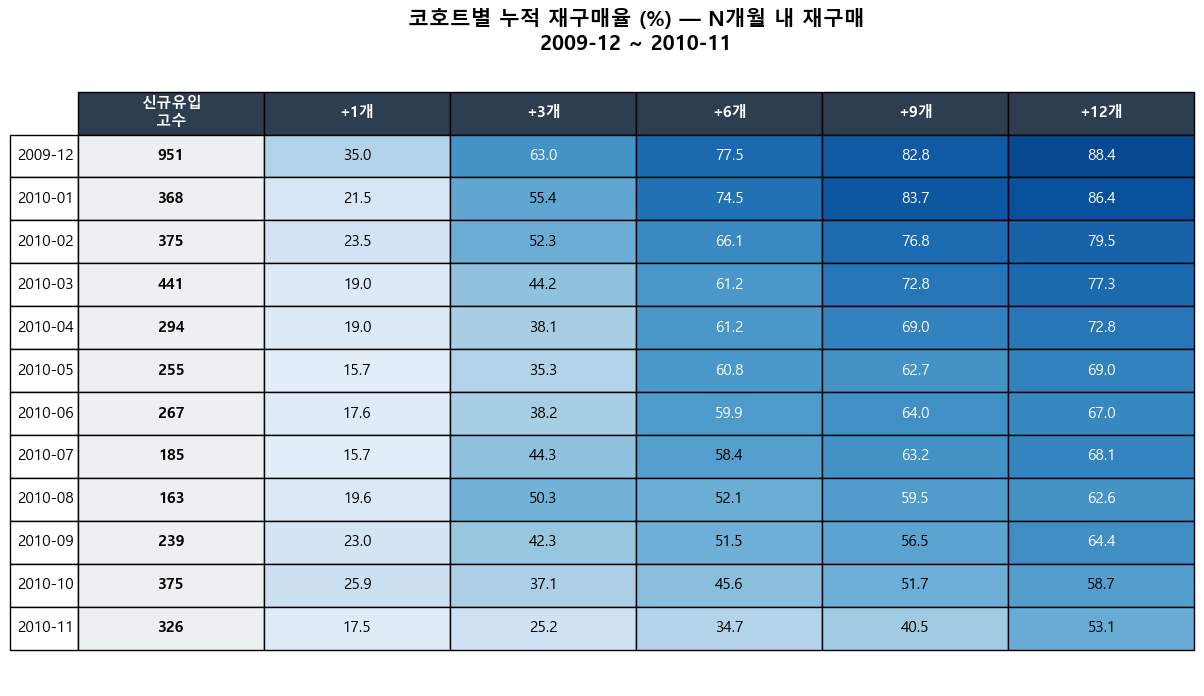

In [ ]:
# ============================================================
# 3. 표 시각화 (재구매율 높을수록 진한 파랑)
# ============================================================
fig, ax = plt.subplots(figsize=(12, 7))
ax.axis('off')

col_labels = ['신규유입\n고수'] + [f'+{p}M' for p in periods]
row_labels = cumulative_df.index.tolist()

cell_text = []
for cohort in cumulative_df.index:
    row = [f"{int(cumulative_df.loc[cohort, '신규유입'])}"]
    for p in periods:
        row.append(f"{cumulative_df.loc[cohort, f'+{p}개월']:.1f}")
    cell_text.append(row)

table = ax.table(cellText=cell_text, rowLabels=row_labels,
                 colLabels=col_labels, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.1, 2.2)

all_vals = cumulative_df[value_cols].values.flatten()
vmin, vmax = all_vals.min(), all_vals.max()
blues = plt.cm.Blues

for i, cohort in enumerate(cumulative_df.index):
    for j, p in enumerate(periods):
        val = cumulative_df.loc[cohort, f'+{p}개월']
        cell = table[i+1, j+1]
        norm = (val - vmin) / (vmax - vmin) if vmax > vmin else 0
        cell.set_facecolor(blues(0.1 + norm * 0.8))
        if norm > 0.6:
            cell.set_text_props(color='white')

for j in range(len(col_labels)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

for i in range(len(row_labels)):
    table[i+1, 0].set_facecolor('#ecf0f1')
    table[i+1, 0].set_text_props(fontweight='bold')

plt.title('코호트별 누적 재구매율 (%) — N개월 내 재구매\n2009-12 ~ 2010-11',
          fontsize=15, fontweight='bold', pad=1)
plt.tight_layout()
plt.savefig('cohort_cumulative_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

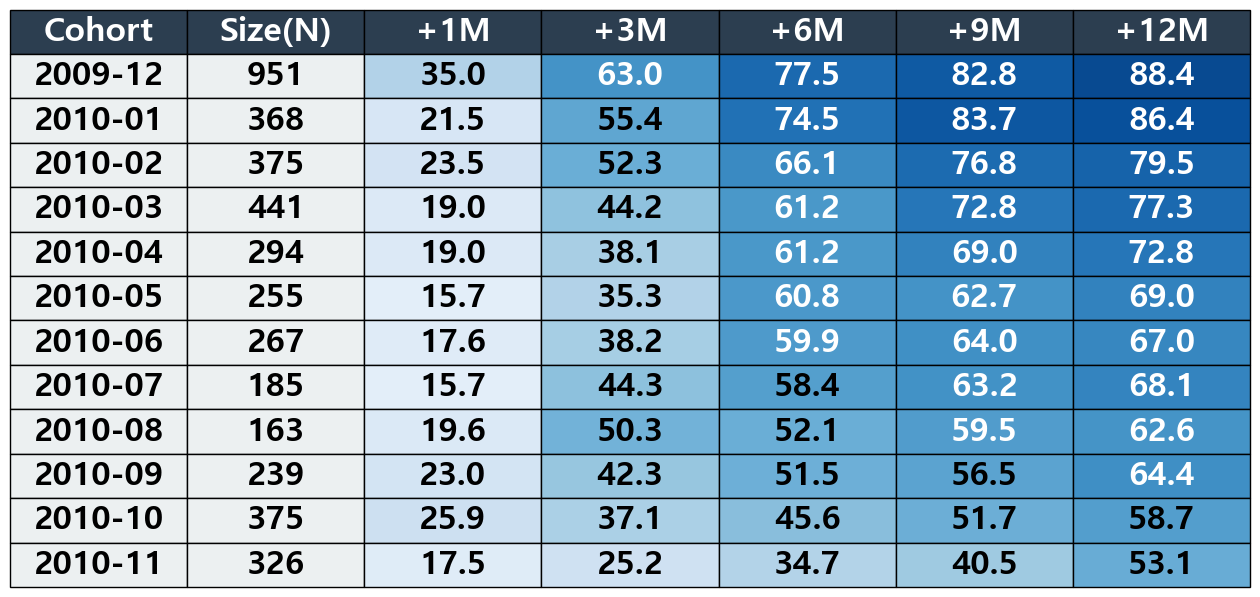

In [28]:
col_labels = ['Cohort', 'Size(N)'] + [f'+{p}M' for p in periods]
row_labels = None                       # rowLabels 안 씀

cell_text = []
for cohort in cumulative_df.index:
    row = [str(cohort), f"{int(cumulative_df.loc[cohort, '신규유입'])}"]
    for p in periods:
        row.append(f"{cumulative_df.loc[cohort, f'+{p}개월']:.1f}")
    cell_text.append(row)

fig, ax = plt.subplots(figsize=(16, 7.5))
ax.axis('off')

table = ax.table(cellText=cell_text, colLabels=col_labels,
                 cellLoc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(24)

# ---- 색상 채우기 ----
all_vals = cumulative_df[value_cols].values.flatten()
vmin, vmax = all_vals.min(), all_vals.max()
blues = plt.cm.Blues

for i in range(len(cumulative_df)):
    for j, p in enumerate(periods):
        val  = cumulative_df.iloc[i][f'+{p}개월']
        cell = table[i+1, j+2]                      # 0=Cohort, 1=Size
        norm = (val - vmin) / (vmax - vmin) if vmax > vmin else 0
        cell.set_facecolor(blues(0.1 + norm * 0.8))
        cell.set_text_props(color='white' if norm > 0.6 else 'black',
                            fontweight='bold')

for j in range(len(col_labels)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

for i in range(len(cumulative_df)):
    for j in (0, 1):
        table[i+1, j].set_facecolor('#ecf0f1')
        table[i+1, j].set_text_props(fontweight='bold')

plt.savefig(r'C:\Users\rladp\Desktop\cohort_table.png', dpi=300, bbox_inches='tight')
plt.show()

raw rows: 1021254
purchase rows: 776579 | customers: 5852
기간: 2009-12-01 ~ 2011-12-09

코호트 수: 25 | 마지막 관측월: 2011-12


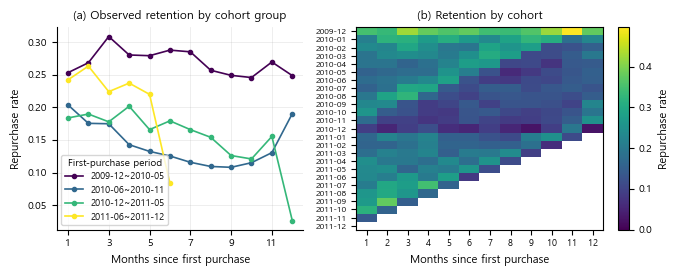


[k=0 리텐션 = 1.0 확인] True

[코호트 규모]
cohort
2009-12    951
2010-01    368
2010-02    375
2010-03    441
2010-04    294
2010-05    255
2010-06    267
2010-07    185
2010-08    163
2010-09    239
2010-10    375
2010-11    326
2010-12     76
2011-01     72
2011-02    125
2011-03    179
2011-04    106
2011-05    111
2011-06    108
2011-07    101
2011-08    107
2011-09    188
2011-10    221
2011-11    191
2011-12     28
Freq: M

[코호트 묶음별 리텐션 곡선]
    2009-12~2010-05  2010-06~2010-11  2010-12~2011-05  2011-06~2011-12
k                                                                     
0            1.0000           1.0000           1.0000           1.0000
1            0.2534           0.2039           0.1839           0.2424
2            0.2686           0.1756           0.1898           0.2634
3            0.3089           0.1749           0.1779           0.2242
4            0.2806           0.1428           0.2018           0.2373
5            0.2794           0.1325           0.1659       

In [15]:
# -*- coding: utf-8 -*-
"""
실측 코호트 리텐션 분석 (Online Retail II / retail_preprocessed.csv)
- 축: (최초구매 코호트 × 경과 개월수), 값: 해당 월에 구매한 고객 비율
- 예측값 미사용. InvoiceDate 기반 실측 집계.
- (a) 코호트 묶음별 리텐션 곡선  (b) 코호트 × 경과월 히트맵(삼각형)
"""
import pandas as pd, numpy as np, matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 0. 설정
# ------------------------------------------------------------------
RAW  = r'C:\Users\rladp\Desktop\ACK_2_Cohort_Transformer\data\retail_preprocessed.csv'
SAVE = r'C:\Users\rladp\Desktop\ACK_2_Cohort_Transformer\data\model'

MAX_K = 12                   # 표시할 최대 경과 개월수
MIN_N = 20                   # 코호트 최소 고객 수
CUT_STARTS = ['2009-12', '2010-06', '2010-12', '2011-06']   # 곡선용 코호트 묶음
ONLY_COMPLETE = True         # True면 관측 안 된 (우측 절단) 칸을 NaN 처리

plt.rcParams.update({'font.size': 8, 'axes.titlesize': 8.5, 'axes.labelsize': 8,
                     'xtick.labelsize': 7.5, 'ytick.labelsize': 7.5,
                     'legend.fontsize': 7, 'legend.title_fontsize': 7.5,
                     'savefig.dpi': 300})

# ------------------------------------------------------------------
# 1. 전처리본 로드 (필요한 3개 컬럼만)
# ------------------------------------------------------------------
tx = pd.read_csv(RAW, usecols=['InvoiceDate', 'Customer ID', 'is_purchase'],
                 parse_dates=['InvoiceDate'], low_memory=False)
print('raw rows:', len(tx))

tx['Customer ID'] = tx['Customer ID'].astype(str).str.replace(r'\.0$', '', regex=True)
tx = tx[tx['is_purchase'].astype(bool)]                       # 취소/반품 제외
tx = tx[tx['Customer ID'].notna() & ~tx['Customer ID'].isin(['nan', ''])]
tx = tx.dropna(subset=['InvoiceDate'])

print('purchase rows:', len(tx), '| customers:', tx['Customer ID'].nunique())
print('기간:', tx['InvoiceDate'].min().date(), '~', tx['InvoiceDate'].max().date())

# ------------------------------------------------------------------
# 2. 코호트 · 경과 개월수
# ------------------------------------------------------------------
tx['order_month'] = tx['InvoiceDate'].dt.to_period('M')
first = tx.groupby('Customer ID')['order_month'].min().rename('cohort')
tx = tx.join(first, on='Customer ID')
tx['k'] = (tx['order_month'] - tx['cohort']).apply(lambda x: x.n)   # 0 = 첫 구매월

LAST_MONTH = tx['order_month'].max()

# (코호트, k)별 활성 고객 수 — 고객 중복 제거
act = (tx.drop_duplicates(['Customer ID', 'cohort', 'k'])
       .groupby(['cohort', 'k'])['Customer ID'].size().unstack(fill_value=0))
size = tx.drop_duplicates('Customer ID').groupby('cohort')['Customer ID'].size()

keep = size[size >= MIN_N].index
act, size = act.loc[keep], size.loc[keep]

ret = act.div(size, axis=0).reindex(columns=range(0, MAX_K + 1))

# 우측 절단: 코호트별 관측 가능한 최대 k 이후는 NaN
if ONLY_COMPLETE:
    for c in ret.index:
        kmax = (LAST_MONTH - c).n
        ret.loc[c, [k for k in ret.columns if k > kmax]] = np.nan

print('\n코호트 수:', len(ret), '| 마지막 관측월:', LAST_MONTH)

# ------------------------------------------------------------------
# 3. 코호트 묶음별 평균 리텐션 곡선 (코호트 규모 가중)
# ------------------------------------------------------------------
starts = pd.PeriodIndex(CUT_STARTS, freq='M')
ends   = list(starts[1:] - 1) + [LAST_MONTH]
blab   = [f'{s}~{e}' for s, e in zip(starts, ends)]

grp = pd.Series(index=ret.index, dtype=object)
for s, e, lb in zip(starts, ends, blab):
    grp[(ret.index >= s) & (ret.index <= e)] = lb
grp = pd.Categorical(grp, categories=blab, ordered=True)

w, curves = size.reindex(ret.index), {}
for lb in blab:
    m = np.asarray(grp == lb)
    if m.sum() == 0:
        continue
    num = ret[m].mul(w[m], axis=0).sum(axis=0, min_count=1)
    den = ret[m].notna().mul(w[m], axis=0).sum(axis=0)
    curves[lb] = num / den.replace(0, np.nan)
curves = pd.DataFrame(curves)

# ------------------------------------------------------------------
# 4. 그림
# ------------------------------------------------------------------
cmap    = plt.get_cmap('viridis')
palette = [cmap(i / max(len(blab) - 1, 1)) for i in range(len(blab))]

fig, ax = plt.subplots(1, 2, figsize=(6.9, 2.8), gridspec_kw={'width_ratios': [1, 1.25]})

ks = [k for k in curves.index if k >= 1]        # k=0은 정의상 100%라 제외
for lb, col in zip(curves.columns, palette):
    ax[0].plot(ks, curves.loc[ks, lb], 'o-', ms=3, lw=1.2, color=col, label=lb)
ax[0].set_xlabel('Months since first purchase')
ax[0].set_ylabel('Repurchase rate')
ax[0].set_title('(a) Observed retention by cohort group')
ax[0].set_xticks(ks[::2] if len(ks) > 8 else ks)
ax[0].grid(alpha=.3, lw=.5)
ax[0].legend(title='First-purchase period', fontsize=6.5, title_fontsize=7)
for s in ('top', 'right'):
    ax[0].spines[s].set_visible(False)

hm = ret[[k for k in ret.columns if k >= 1]]
im = ax[1].imshow(hm.values, aspect='auto', cmap='viridis', vmin=0)
ax[1].set_xticks(range(hm.shape[1])); ax[1].set_xticklabels(hm.columns, fontsize=6.5)
ax[1].set_yticks(range(len(hm.index)))
ax[1].set_yticklabels([str(c) for c in hm.index], fontsize=6)
ax[1].set_xlabel('Months since first purchase')
ax[1].set_title('(b) Retention by cohort')
plt.colorbar(im, ax=ax[1], label='Repurchase rate')

fig.tight_layout()
fig.savefig(SAVE + r'\fig_cohort_retention.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------
# 5. 검증용 수치
# ------------------------------------------------------------------
print('\n[k=0 리텐션 = 1.0 확인]', bool((ret[0].dropna() == 1.0).all()))
print('\n[코호트 규모]'); print(size.to_string())
print('\n[코호트 묶음별 리텐션 곡선]'); print(curves.round(4).to_string())
print('\n[코호트 × 경과월 리텐션]');   print(ret.round(3).to_string())